# 03 · Stochastic State Estimation and the Kalman Filter
**Based on:** *Estimation in Information Fusion* — W. Dale Blair, FUSION Boot Camp 2026, part 2.

In notebook 02 we estimated a **stationary** parameter. Now the state **evolves in time** (position, velocity, 
acceleration). **The Kalman filter is the 'workhorse' of target tracking** and gives the MMSE estimate when the errors are Gaussian.

## A. The discrete-time model
$$x_{k+1} = F_k\,x_k + G_k\,v_k, \qquad z_k = H_k\,x_k + w_k$$

* $x_k$ — the state vector (position, velocity, possibly acceleration).
* $v_k\sim\mathcal{N}(0,Q_k)$ — **process noise** (plant noise).
* $w_k\sim\mathcal{N}(0,R_k)$ — measurement noise.
* $F$ — the transition matrix (the kinematic motion constraint); $H$ — relates measurements to the state (nonlinear forms → EKF, notebook 04).

**Process noise is the essential difference** between the Kalman filter (stochastic state estimation) and LSE 
(parameter estimation): it captures the uncertainty in the evolution/modeling of the state from step $k$ to $k{+}1$, zero-mean and white.

## B. Deriving the Kalman filter — predictor / corrector
The filter is a **predictor–corrector** algorithm:

**Time Update (Predict):**
$$\hat{x}_{k|k-1}=F_{k-1}\hat{x}_{k-1|k-1}, \qquad P_{k|k-1}=F_{k-1}P_{k-1|k-1}F_{k-1}^{T}+G_{k-1}Q_{k-1}G_{k-1}^{T}$$

**Measurement Update (Correct):**
$$S_k = H_kP_{k|k-1}H_k^{T}+R_k \quad(\text{innovation covariance})$$
$$K_k = P_{k|k-1}H_k^{T}S_k^{-1} \quad(\text{Kalman gain})$$
$$\hat{x}_{k|k}=\hat{x}_{k|k-1}+K_k\,[\,z_k-H_k\hat{x}_{k|k-1}\,]$$
$$P_{k|k}=(I-K_kH_k)\,P_{k|k-1}$$

The gain $K_k$ balances trust in the model (predict) against trust in the measurement: large $R$ → small $K$ (trust the model), and vice versa.

> **Slide warning:** the Kalman filter assumes **perfect measurement-to-track association** — exactly where data association enters (Meyer's lecture).

## C. The NCV model and process noise (DWNA vs CWNA)
**Nearly Constant Velocity (NCV)** — the most widely used model in tracking. State vector $x=[p,\dot p]^T$:

$$F=\begin{bmatrix}1 & T\\ 0 & 1\end{bmatrix},\quad H=\begin{bmatrix}1 & 0\end{bmatrix}$$

Two common ways to model the process noise (unplanned acceleration with variance $\sigma_a^2$ or PSD $q$):

**DWNA — Discrete White Noise Acceleration:**
$$Q = \Gamma\Gamma^{T}\sigma_a^2,\quad \Gamma=\begin{bmatrix}T^2/2\\ T\end{bmatrix} \Rightarrow Q=\sigma_a^2\begin{bmatrix}T^4/4 & T^3/2\\ T^3/2 & T^2\end{bmatrix}$$

**CWNA — Continuous White Noise Acceleration:**
$$Q = q\begin{bmatrix}T^3/3 & T^2/2\\ T^2/2 & T\end{bmatrix}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(7)

def ncv_matrices(T, kind='DWNA', sigma_a=1.0):
    F = np.array([[1, T],[0, 1.0]])
    H = np.array([[1.0, 0.0]])
    if kind == 'DWNA':
        G = np.array([[T**2/2],[T]])
        Q = (G @ G.T) * sigma_a**2
    else:  # CWNA
        Q = sigma_a**2 * np.array([[T**3/3, T**2/2],[T**2/2, T]])
    return F, H, Q

class KalmanFilter:
    def __init__(self, F, H, Q, R, x0, P0):
        self.F,self.H,self.Q,self.R = map(np.atleast_2d,(F,H,Q,R))
        self.x = np.asarray(x0,float).reshape(-1,1)
        self.P = np.atleast_2d(P0).astype(float)
    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x.ravel()
    def update(self, z):
        z = np.atleast_2d(np.asarray(z,float).reshape(-1,1))
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        y = z - self.H @ self.x
        self.x = self.x + K @ y
        I = np.eye(self.P.shape[0])
        self.P = (I - K @ self.H) @ self.P
        return self.x.ravel(), y.item(), S.item()

print('Kalman filter + NCV models defined.')

Kalman filter + NCV models defined.


## D. Simulation: NCV tracking of a constant-velocity target
A target moves at constant velocity; the sensor measures **only position** with noise $\sigma_w$. 
The filter estimates position and **velocity** (which is not measured directly) — the power of state estimation.

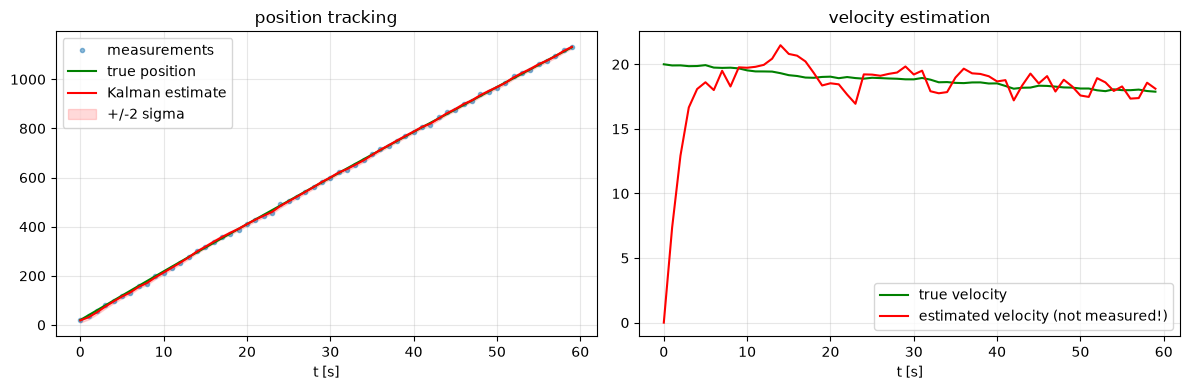

position RMSE: raw=4.35 m, filtered=3.41 m


In [2]:
T, steps = 1.0, 60
sigma_w = 5.0          # measurement noise [m]
sigma_a_true = 0.1     # small true maneuver
F, H, _ = ncv_matrices(T)
Qsim = ncv_matrices(T, 'DWNA', sigma_a_true)[2]

# generate the ground-truth trajectory
x = np.array([[0.],[20.]])   # position 0, velocity 20 m/s
truth, meas = [], []
Lq = np.linalg.cholesky(Qsim + 1e-12*np.eye(2))
for _ in range(steps):
    x = F @ x + Lq @ rng.standard_normal((2,1))
    truth.append(x.ravel().copy())
    meas.append((H @ x).item() + sigma_w*rng.standard_normal())
truth = np.array(truth); meas = np.array(meas)

# run the filter
Fk, Hk, Qk = ncv_matrices(T, 'DWNA', sigma_a=1.0)
kf = KalmanFilter(Fk, Hk, Qk, R=sigma_w**2, x0=[meas[0],0], P0=np.diag([sigma_w**2,100]))
est_pos, est_vel, pos_std = [], [], []
for z in meas:
    kf.predict()
    xe,_,_ = kf.update(z)
    est_pos.append(xe[0]); est_vel.append(xe[1]); pos_std.append(np.sqrt(kf.P[0,0]))
est_pos,est_vel,pos_std = map(np.array,(est_pos,est_vel,pos_std))

t = np.arange(steps)*T
fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(t, meas,'.',alpha=.5,label='measurements')
ax[0].plot(t, truth[:,0],'g',label='true position')
ax[0].plot(t, est_pos,'r',label='Kalman estimate')
ax[0].fill_between(t, est_pos-2*pos_std, est_pos+2*pos_std, color='r', alpha=.15, label='+/-2 sigma')
ax[0].set_title('position tracking'); ax[0].legend(); ax[0].grid(alpha=.3); ax[0].set_xlabel('t [s]')
ax[1].plot(t, truth[:,1],'g',label='true velocity')
ax[1].plot(t, est_vel,'r',label='estimated velocity (not measured!)')
ax[1].set_title('velocity estimation'); ax[1].legend(); ax[1].grid(alpha=.3); ax[1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()
print(f'position RMSE: raw={np.sqrt(np.mean((meas-truth[:,0])**2)):.2f} m,'
      f' filtered={np.sqrt(np.mean((est_pos-truth[:,0])**2)):.2f} m')

## E. The role of process noise and gain convergence
When $Q$ and $R$ are constant, the covariance $P$ and the gain $K$ converge to a steady state. 
The smaller $Q$ is, the more the filter 'trusts' the model, the smaller the gain, and the smoother but slower-to-maneuver the estimate (notebook 04).

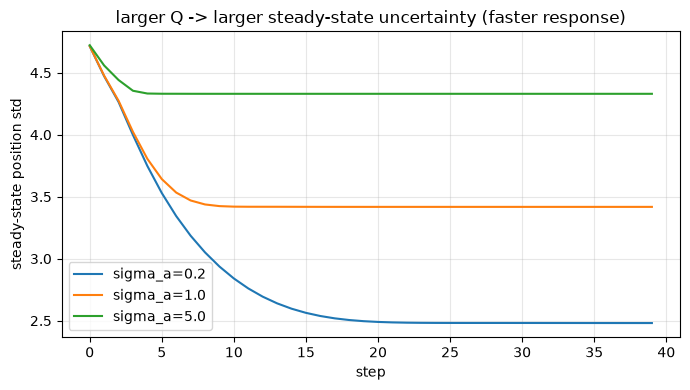

In [3]:
# gain / position-std convergence for different sigma_a values
plt.figure(figsize=(7,4))
for sa in [0.2, 1.0, 5.0]:
    Fk,Hk,Qk = ncv_matrices(T,'DWNA',sigma_a=sa)
    kf = KalmanFilter(Fk,Hk,Qk,R=sigma_w**2,x0=[0,0],P0=np.diag([100.,100.]))
    stds=[]
    for _ in range(40):
        kf.predict(); kf.update(0.0); stds.append(np.sqrt(kf.P[0,0]))
    plt.plot(stds, label=f'sigma_a={sa}')
plt.xlabel('step'); plt.ylabel('steady-state position std')
plt.title('larger Q -> larger steady-state uncertainty (faster response)')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## F. Consistency check (normalized innovation)
A consistent filter produces innovations that match the covariance $S_k$ it predicts. 
A common diagnostic: the normalized innovation $y_k/\sqrt{S_k}$ should be distributed as $\mathcal{N}(0,1)$.

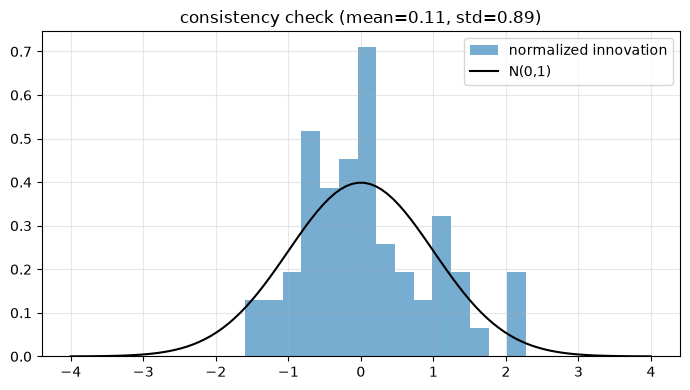

In [4]:
kf = KalmanFilter(Fk:=ncv_matrices(T,'DWNA',1.0)[0], ncv_matrices(T)[1],
                  ncv_matrices(T,'DWNA',1.0)[2], R=sigma_w**2,
                  x0=[meas[0],0], P0=np.diag([sigma_w**2,100]))
norm_innov=[]
for z in meas:
    kf.predict(); _,y,S = kf.update(z); norm_innov.append(y/np.sqrt(S))
norm_innov=np.array(norm_innov)
plt.figure(figsize=(7,4))
plt.hist(norm_innov, bins=15, density=True, alpha=.6, label='normalized innovation')
xx=np.linspace(-4,4,100); plt.plot(xx, np.exp(-xx**2/2)/np.sqrt(2*np.pi),'k',label='N(0,1)')
plt.title(f'consistency check (mean={norm_innov.mean():.2f}, std={norm_innov.std():.2f})')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Summary
* **The Kalman filter = predictor–corrector**; gives the MMSE under linearity + Gaussianity.
* **Process noise** ($Q$, in DWNA/CWNA form) distinguishes state estimation from parameter estimation and controls the model↔measurement balance.
* The **NCV** model estimates velocity even when only position is measured, and significantly reduces the position error relative to the raw measurement.
* The filter assumes **perfect association** and a **single** model — two assumptions relaxed in notebook 04 (maneuvers, IMM, nonlinearity).